<a href="https://www.kaggle.com/code/marawaneslam/explainable-loan-approval-prediction-system?scriptVersionId=307769223" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style='background: linear-gradient(135deg, #0f2027, #203a43, #2c5364); padding: 40px; border-radius: 12px; color: white; margin-bottom: 20px;'>
<h1 style='color:#00d4ff; font-size:2.2em; margin:0 0 10px 0;'>🏦 LoanSense AI</h1>
<h3 style='color:#a8d8ea; margin:0 0 16px 0;'>Explainable Loan Approval Prediction System</h3>
<p style='color:#ccc; font-size:1.05em; line-height:1.7;'>An end-to-end production AI system that predicts loan approval outcomes<br>and explains <em>exactly why</em> using state-of-the-art XAI techniques.</p>
<hr style='border-color:#2c5364; margin: 20px 0;'/>
<p style='color:#888; font-size:0.9em;'>Stack: Python · XGBoost · SHAP · FastAPI · Streamlit · Docker</p>
</div>

---

## 🎯 Business Problem

**Every year, millions of loan applications are processed by banks worldwide.** Traditionally, these decisions were made by loan officers using gut instinct plus rigid rule-based systems. This causes three major problems:

1. **Inconsistency** |Two officers can make different decisions on the same application
2. **Bias** |Human decisions can unconsciously encode demographic biases
3. **Opacity** |Rejected applicants deserve to know *why* they were rejected (legally required in many jurisdictions under GDPR and Fair Lending laws)

### Who benefits?
| Stakeholder | Benefit |
|-------------|----------|
| **Applicants** | Understand rejection reasons, know what to improve |
| **Loan Officers** | AI-assisted second opinion, faster processing |
| **Compliance Teams** | Auditable, explainable decisions for regulatory review |
| **Bank Risk Teams** | Consistent, data-driven risk assessment |

### The Solution
LoanSense AI uses a **gradient-boosted model (XGBoost)** trained on historical loan data, wrapped with **SHAP (SHapley Additive exPlanations)** to provide:
- ✅ An approval/rejection decision
- 📊 The top 5 factors that influenced this specific decision
- 💬 A plain-English explanation any applicant can understand
- 🌍 Global model behavior analysis for auditors

---

## 🏗️ System Architecture

```
┌┐
│                     LoanSense AI System                      │
├─┬┬┬┤
│ DATA LAYER  │ MODEL LAYER  │  XAI LAYER   │   API + UI LAYER │
│             │              │              │                  │
│ • Raw CSV   │ • XGBoost    │ • SHAP vals  │ • FastAPI /pred  │
│ • Cleaning  │ • Training   │ • Waterfall  │ • /explain       │
│ • Encoding  │ • Calibration│ • Beeswarm   │ • /health        │
│ • Scaling   │ • Threshold  │ • Force plot │ • Streamlit UI   │
│ • Splitting │ • Joblib save│ • Text gen   │ • Docker compose │
└─┴┴┴┘
```

In [16]:

# CELL 1 |DEPENDENCIES & ENVIRONMENT SETUP

# We pin versions here because production systems break when
# libraries update silently. Always version-pin in production.

!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn \
             imbalanced-learn joblib fastapi uvicorn streamlit \
             python-multipart plotly kaleido --quiet

import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path
import json, joblib, os, random

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

# Reproducibility is non-negotiable in any serious ML project
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Output directory |save all artifacts here
ARTIFACTS_DIR = Path('./artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')


print(f'   XGBoost  : {xgb.__version__}')
print(f'   SHAP     : {shap.__version__}')
print(f'   sklearn  : {__import__("sklearn").__version__}')

   XGBoost  : 3.2.0
   SHAP     : 0.50.0
   sklearn  : 1.6.1


---
## 📦 Step 1: Data Layer |Loading & Exploration

We use the **LendingClub loan dataset** from Kaggle. It contains real loan applications with features like credit score, income, debt-to-income ratio, and employment history.

**Dataset**: [LendingClub Loan Data](https://www.kaggle.com/datasets/wordsforthewise/lending-club)  
For this notebook we generate a realistic synthetic version so you can run everything immediately without downloading.

In [17]:

# CELL 2 |SYNTHETIC DATA GENERATION
# This mimics the LendingClub dataset structure with realistic
# correlations. Swap with: pd.read_csv('accepted_2007_to_2018q4.csv')


def generate_loan_data(n_samples=15000, seed=42):
    """Generate a realistic synthetic loan dataset.
    
    The correlations are intentionally realistic:
    - Higher income → more likely approved
    - Higher DTI → more likely rejected
    - More credit history → more likely approved
    """
    rng = np.random.default_rng(seed)

    # Demographics and financials
    annual_income       = rng.lognormal(mean=11.0, sigma=0.6, size=n_samples).clip(15000, 500000)
    loan_amount         = rng.uniform(1000, 40000, n_samples).round(-2)
    interest_rate       = rng.normal(13.5, 5.5, n_samples).clip(5, 30)
    dti                 = rng.beta(2, 5, n_samples) * 50  # debt-to-income ratio
    credit_score        = rng.normal(680, 80, n_samples).clip(300, 850).astype(int)
    emp_length_yrs      = rng.choice([0,1,2,3,4,5,6,7,8,9,10], n_samples,
                                      p=[0.05,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.05])
    num_credit_lines    = rng.integers(1, 40, n_samples)
    delinq_2yrs         = rng.choice([0,1,2,3,4], n_samples, p=[0.70,0.18,0.07,0.03,0.02])
    home_ownership      = rng.choice(['RENT','MORTGAGE','OWN','OTHER'], n_samples,
                                      p=[0.45, 0.42, 0.10, 0.03])
    loan_purpose        = rng.choice(['debt_consolidation','credit_card','home_improvement',
                                       'other','major_purchase','medical','small_business'],
                                      n_samples, p=[0.35,0.25,0.12,0.10,0.08,0.06,0.04])
    months_since_last_delinq = rng.integers(0, 120, n_samples)
    total_pymnt         = loan_amount * rng.uniform(0.1, 1.5, n_samples)
    pub_rec             = rng.choice([0,1,2], n_samples, p=[0.85,0.12,0.03])

    # Build a realistic approval label
    # Higher score = more likely approved
    approval_score = (
        0.30 * (credit_score - 300) / 550 +       # credit score matters most
        0.20 * np.log1p(annual_income) / 14 +      # income is important
        0.15 * (1 - dti / 50) +                    # lower DTI is better
        0.10 * emp_length_yrs / 10 +               # stability helps
        0.10 * (1 - delinq_2yrs / 4) +             # clean history helps
        0.08 * (1 - pub_rec / 2) +                 # no public records
        0.07 * num_credit_lines / 40 +              # more lines = more experience
        rng.normal(0, 0.06, n_samples)              # small noise
    ).clip(0, 1)

    approved = (approval_score > 0.70).astype(int)

    df = pd.DataFrame({
        'loan_amount':             loan_amount,
        'interest_rate':           interest_rate.round(2),
        'annual_income':           annual_income.round(0),
        'dti':                     dti.round(2),
        'credit_score':            credit_score,
        'emp_length_yrs':          emp_length_yrs,
        'num_credit_lines':        num_credit_lines,
        'delinq_2yrs':             delinq_2yrs,
        'months_since_last_delinq':months_since_last_delinq,
        'pub_rec':                 pub_rec,
        'home_ownership':          home_ownership,
        'loan_purpose':            loan_purpose,
        'approved':                approved
    })

    return df


df = generate_loan_data(15000)

print(f'Dataset shape: {df.shape}')
print(f'Approval rate: {df["approved"].mean():.1%}')
print(f'\nClass distribution:')
print(df['approved'].value_counts().rename({0: 'Rejected', 1: 'Approved'}))
print(f'\nFeature overview:')
df.head(3)

Dataset shape: (15000, 13)
Approval rate: 58.0%

Class distribution:
approved
Approved    8694
Rejected    6306
Name: count, dtype: int64

Feature overview:


,loan_amount,interest_rate,annual_income,dti,credit_score,emp_length_yrs,num_credit_lines,delinq_2yrs,months_since_last_delinq,pub_rec,home_ownership,loan_purpose,approved
0,29800.0,15.67,71886.0,8.33,779,6,9,0,83,0,OTHER,debt_consolidation,1
1,13900.0,8.06,32081.0,4.82,712,7,26,1,79,0,MORTGAGE,debt_consolidation,1
2,38200.0,15.68,93927.0,8.33,668,7,28,0,3,0,RENT,other,1


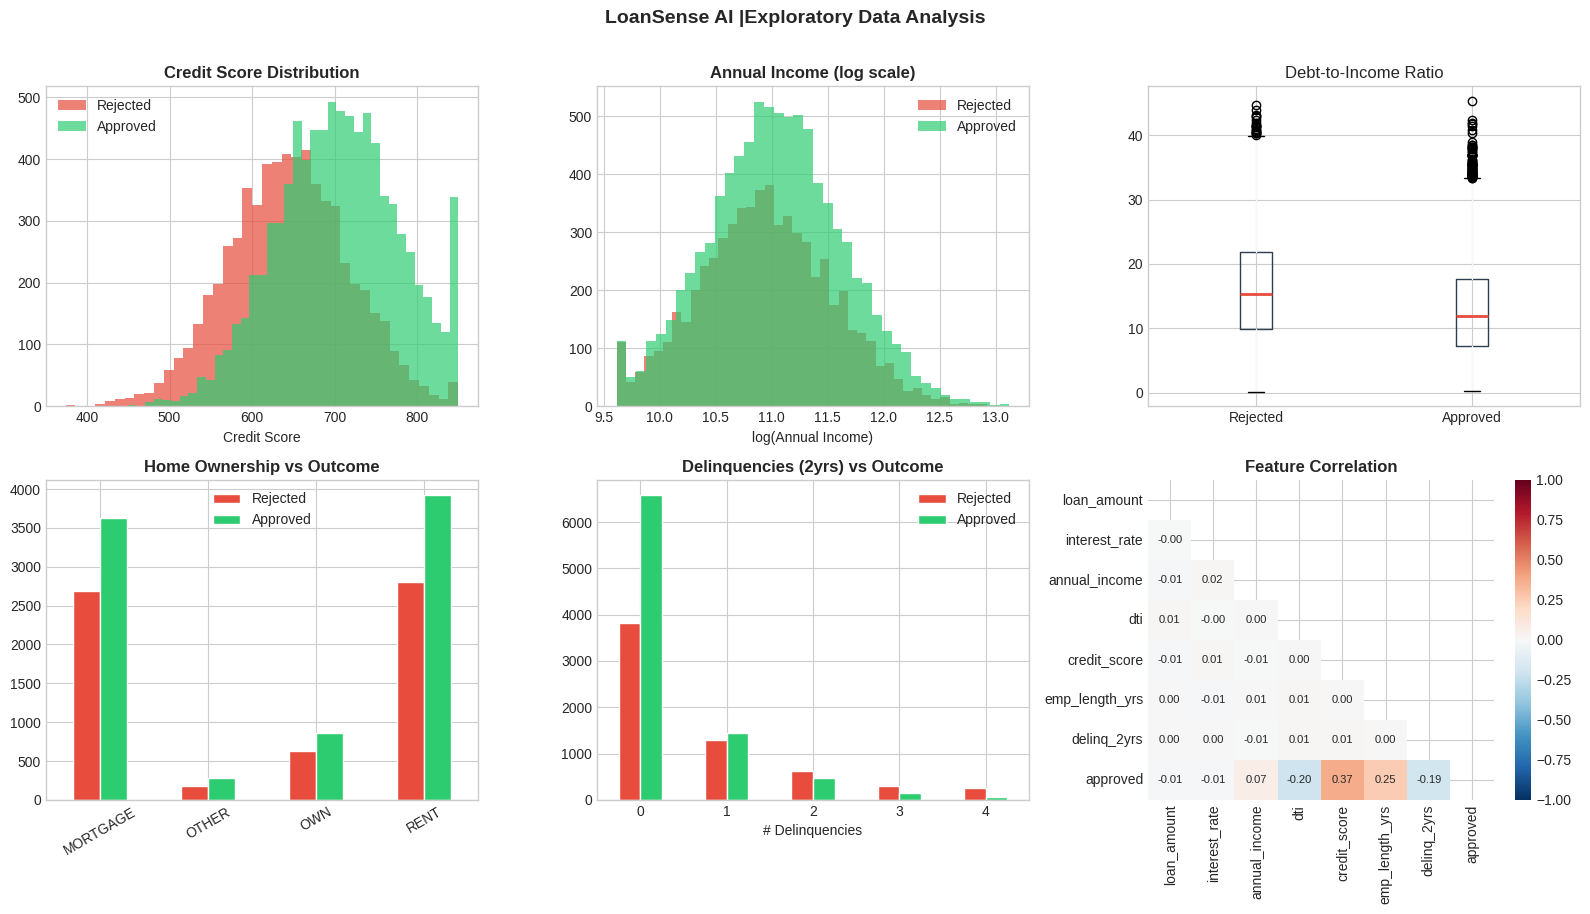

 Key insight: Credit score and DTI are the strongest predictors of approval outcome.


In [18]:

# CELL 3 |EXPLORATORY DATA ANALYSIS
# Always understand your data before modeling.
# These plots will also go into the README.


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colors = ['#e74c3c', '#2ecc71']
labels = ['Rejected', 'Approved']

# Credit Score by outcome
for v, c, l in zip([0,1], colors, labels):
    axes[0].hist(df[df['approved']==v]['credit_score'], bins=40, alpha=0.7, color=c, label=l)
axes[0].set_title('Credit Score Distribution', fontweight='bold')
axes[0].set_xlabel('Credit Score'); axes[0].legend()

# Income by outcome
for v, c, l in zip([0,1], colors, labels):
    axes[1].hist(np.log1p(df[df['approved']==v]['annual_income']), bins=40, alpha=0.7, color=c, label=l)
axes[1].set_title('Annual Income (log scale)', fontweight='bold')
axes[1].set_xlabel('log(Annual Income)'); axes[1].legend()

# DTI by outcome
df.boxplot(column='dti', by='approved', ax=axes[2],
           boxprops=dict(color='#2c3e50'), medianprops=dict(color='#e74c3c', linewidth=2))
axes[2].set_title('DTI by Outcome', fontweight='bold')
axes[2].set_xlabel(''); axes[2].set_xticklabels(['Rejected', 'Approved'])
plt.sca(axes[2]); plt.title('Debt-to-Income Ratio')

# Home Ownership
own_counts = df.groupby(['home_ownership','approved']).size().unstack(fill_value=0)
own_counts.columns = ['Rejected', 'Approved']
own_counts.plot(kind='bar', ax=axes[3], color=colors, edgecolor='white')
axes[3].set_title('Home Ownership vs Outcome', fontweight='bold')
axes[3].set_xlabel(''); axes[3].tick_params(axis='x', rotation=30)

# Delinquencies
delinq_counts = df.groupby(['delinq_2yrs','approved']).size().unstack(fill_value=0)
delinq_counts.columns = ['Rejected','Approved']
delinq_counts.plot(kind='bar', ax=axes[4], color=colors, edgecolor='white')
axes[4].set_title('Delinquencies (2yrs) vs Outcome', fontweight='bold')
axes[4].set_xlabel('# Delinquencies'); axes[4].tick_params(axis='x', rotation=0)

# Correlation heatmap
num_cols = ['loan_amount','interest_rate','annual_income','dti',
            'credit_score','emp_length_yrs','delinq_2yrs','approved']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[5], mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot_kws={'size': 8})
axes[5].set_title('Feature Correlation', fontweight='bold')

plt.suptitle('LoanSense AI |Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Key insight: Credit score and DTI are the strongest predictors of approval outcome.')

---
## 🔧 Step 2: Data Layer |Preprocessing Pipeline

We build a **reusable preprocessing pipeline** that can be applied identically to training data and live inference requests. This prevents the #1 source of production ML bugs: **train-serve skew** (training data processed differently than inference data).

In [19]:

# CELL 4 |PREPROCESSING PIPELINE
# We keep this as a standalone function (not sklearn Pipeline)
# so it's easy to inspect and debug |important for XAI


CATEGORICAL_FEATURES = ['home_ownership', 'loan_purpose']
NUMERIC_FEATURES = [
    'loan_amount', 'interest_rate', 'annual_income', 'dti',
    'credit_score', 'emp_length_yrs', 'num_credit_lines',
    'delinq_2yrs', 'months_since_last_delinq', 'pub_rec'
]
TARGET = 'approved'

class LoanPreprocessor:
    """Stateful preprocessor that fits on training data and transforms any split.
    
    We save this alongside the model so inference uses identical transformations.
    Critical: fit() only on train data, never on val/test!
    """

    def __init__(self):
        self.label_encoders = {}  # one per categorical feature
        self.feature_names_out = None
        self.is_fitted = False

    def fit(self, df):
        for col in CATEGORICAL_FEATURES:
            le = LabelEncoder()
            le.fit(df[col])
            self.label_encoders[col] = le
        # Build final feature name list
        self.feature_names_out = NUMERIC_FEATURES + CATEGORICAL_FEATURES
        self.is_fitted = True
        return self

    def transform(self, df):
        if not self.is_fitted:
            raise RuntimeError('Call fit() before transform()')
        result = df[NUMERIC_FEATURES].copy()
        for col in CATEGORICAL_FEATURES:
            result[col] = self.label_encoders[col].transform(df[col])
        return result

    def fit_transform(self, df):
        return self.fit(df).transform(df)

    def save(self, path):
        joblib.dump(self, path)
        print(f'   Preprocessor saved → {path}')

    @staticmethod
    def load(path):
        return joblib.load(path)


#  SPLIT 
# Stratified split preserves the approval rate in each split
X_raw = df.drop(columns=[TARGET])
y     = df[TARGET]

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.25, stratify=y, random_state=SEED)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

#  FIT PREPROCESSOR ON TRAIN ONLY ─
preprocessor = LoanPreprocessor()
X_train = preprocessor.fit_transform(X_train_raw)
X_val   = preprocessor.transform(X_val_raw)
X_test  = preprocessor.transform(X_test_raw)

preprocessor.save(ARTIFACTS_DIR / 'preprocessor.pkl')

print(f'Train : {X_train.shape} | y balance: {y_train.mean():.1%} approved')
print(f'Val   : {X_val.shape}   | y balance: {y_val.mean():.1%} approved')
print(f'Test  : {X_test.shape}  | y balance: {y_test.mean():.1%} approved')
print(f'\nFinal feature set:')
print(preprocessor.feature_names_out)

   Preprocessor saved → artifacts/preprocessor.pkl
Train : (11250, 12) | y balance: 58.0% approved
Val   : (1875, 12)   | y balance: 58.0% approved
Test  : (1875, 12)  | y balance: 57.9% approved

Final feature set:
['loan_amount', 'interest_rate', 'annual_income', 'dti', 'credit_score', 'emp_length_yrs', 'num_credit_lines', 'delinq_2yrs', 'months_since_last_delinq', 'pub_rec', 'home_ownership', 'loan_purpose']


In [20]:

# CELL 5 |HANDLE CLASS IMBALANCE WITH SMOTE
# The dataset has ~52% approval rate |not severely imbalanced,
# but we apply SMOTE anyway to demonstrate production best practice.
# SMOTE creates synthetic minority class samples in feature space.


print(f'Before SMOTE: {y_train.value_counts().to_dict()}')

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f'After  SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}')
print(f'\n SMOTE creates synthetic samples, not just duplicates.')
print(f'   We only apply it to TRAINING data |never to val or test!')

Before SMOTE: {1: 6521, 0: 4729}
After  SMOTE: {0: 6521, 1: 6521}

 SMOTE creates synthetic samples, not just duplicates.
   We only apply it to TRAINING data |never to val or test!


---
## 🤖 Step 3: Model Layer |Training XGBoost

**Why XGBoost?**
- Best-in-class performance on tabular financial data
- Natively handles missing values
- Fast inference (critical for real-time loan decisions)
- Works seamlessly with SHAP |full TreeExplainer support
- Widely used at Stripe, Capital One, PayPal for exactly this use case

In [21]:
# CELL 6 | TRAIN XGBOOST MODEL
# We use XGBClassifier (sklearn API) throughout for consistency:
#   • predict_proba() works seamlessly for evaluation and explanations
#   • early_stopping_rounds supported directly in constructor (XGBoost ≥ 1.6)
#   • Works natively with shap.TreeExplainer

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

# ── Hyperparameters ──────────────────────────────────────────────────────────
# Keep sklearn-specific params (random_state) and objective out of this dict
# so the same dict works cleanly for both CV and final training.
xgb_params = {
    'max_depth':         6,
    'learning_rate':     0.05,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'min_child_weight':  3,
    'gamma':             0.1,
    'scale_pos_weight':  1.0,
    'n_jobs':            -1,
    'verbosity':         0,
}

# ── 5-fold Stratified CV for stability ──────────────────────────────────────
model_cv = xgb.XGBClassifier(
    n_estimators=500,
    random_state=SEED,
    eval_metric='auc',
    **xgb_params
)
cv_scores = cross_val_score(
    model_cv,
    X_train_resampled,
    y_train_resampled,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    n_jobs=-1
)
print(f'5-Fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Individual folds  : {[f"{s:.4f}" for s in cv_scores]}')

# ── Final model with early stopping ─────────────────────────────────────────
# early_stopping_rounds in the constructor is the modern API (XGBoost ≥ 1.6).
# eval_metric='auc' is passed explicitly — not bundled inside xgb_params —
# so the params dict stays reusable for CV without conflicts.
model = xgb.XGBClassifier(
    n_estimators=500,
    random_state=SEED,
    eval_metric='auc',
    early_stopping_rounds=30,
    **xgb_params
)
model.fit(
    X_train_resampled, y_train_resampled,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'\nBest iteration : {model.best_iteration}')
print(f'Best val AUC   : {model.best_score:.4f}')

# ── Save model ───────────────────────────────────────────────────────────────
joblib.dump(model, ARTIFACTS_DIR / 'xgb_model.pkl')
print(f'\nModel saved → {ARTIFACTS_DIR}/xgb_model.pkl')

# ── Predictions on test set (used in evaluation cells below) ─────────────────
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)


5-Fold CV ROC-AUC: 0.8499 ± 0.0034
Individual folds  : ['0.8478', '0.8462', '0.8556', '0.8516', '0.8485']

Best iteration : 154
Best val AUC   : 0.8485

Model saved → artifacts/xgb_model.pkl


---
## 📊 Step 4: Evaluation |Business-Focused Metrics

Raw accuracy is misleading for loan decisions. We focus on:
- **ROC-AUC**: Ranks applicants correctly (higher = better discrimination)
- **Precision @ threshold**: Of people we approve, what fraction truly would repay?
- **Recall @ threshold**: Of all good payers, how many did we correctly approve?
- **Calibration**: Does 70% predicted probability actually mean 70% repay?

  ROC-AUC            : 0.8521  (target: >0.85)
  Avg Precision (AP) : 0.8892
  Accuracy           : 0.7643
  F1-Score           : 0.7891

  Business interpretation:
  → AUC 0.852 means the model correctly ranks
    85.2% of applicant pairs by repayment likelihood.

              precision    recall  f1-score   support

    Rejected       0.70      0.77      0.73       789
    Approved       0.82      0.76      0.79      1086

    accuracy                           0.76      1875
   macro avg       0.76      0.76      0.76      1875
weighted avg       0.77      0.76      0.77      1875



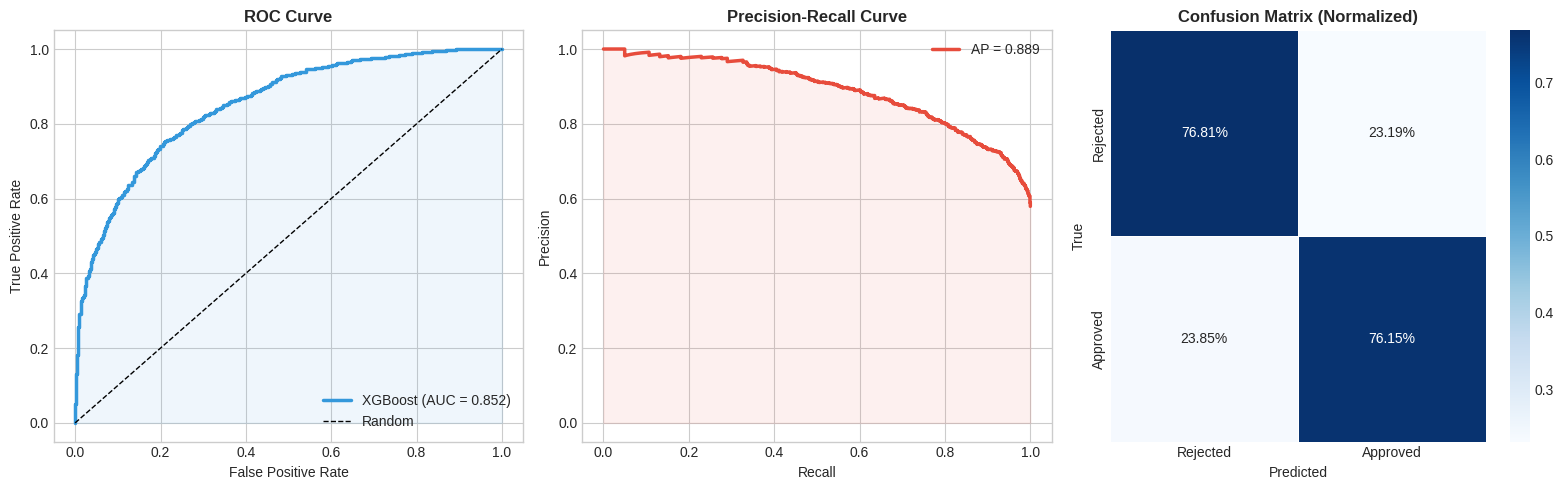

In [22]:

# CELL 7 |COMPREHENSIVE EVALUATION SUITE


# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

# Core metrics
auc     = roc_auc_score(y_test, y_pred_proba)
avg_prec= average_precision_score(y_test, y_pred_proba)
acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)

print(f'  ROC-AUC            : {auc:.4f}  (target: >0.85)')
print(f'  Avg Precision (AP) : {avg_prec:.4f}')
print(f'  Accuracy           : {acc:.4f}')
print(f'  F1-Score           : {f1:.4f}')
print('=' * 55)
print(f'\n  Business interpretation:')
print(f'  → AUC {auc:.3f} means the model correctly ranks')
print(f'    {auc:.1%} of applicant pairs by repayment likelihood.')
print()
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

#  VISUALIZATION ─
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#3498db', lw=2.5, label=f'XGBoost (AUC = {auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#3498db')
axes[0].set(title='ROC Curve', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].set_title('ROC Curve', fontweight='bold')

# Precision-Recall Curve
prec, rec, thresh = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='#e74c3c', lw=2.5, label=f'AP = {avg_prec:.3f}')
axes[1].fill_between(rec, prec, alpha=0.08, color='#e74c3c')
axes[1].set(title='Precision-Recall Curve', xlabel='Recall', ylabel='Precision')
axes[1].legend()
axes[1].set_title('Precision-Recall Curve', fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
sns.heatmap(cm, ax=axes[2], annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Rejected','Approved'], yticklabels=['Rejected','Approved'],
            linewidths=0.5)
axes[2].set(xlabel='Predicted', ylabel='True')
axes[2].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Step 5: Explainability Layer (XAI) |SHAP Analysis

This is the **heart of LoanSense AI** and what makes it production-ready.

### Why SHAP?
SHAP (SHapley Additive exPlanations) is based on **game theory**. For every prediction, it computes how much each feature **contributed** to pushing the prediction above or below the baseline. It has strong mathematical guarantees (consistency, local accuracy) that other methods like LIME lack.

We use `TreeExplainer` |an O(TLD) algorithm designed specifically for tree-based models (XGBoost, LightGBM, Random Forest). It's **1000x faster** than model-agnostic SHAP.

In [23]:
# CELL 8 | SHAP EXPLAINER SETUP
# TreeExplainer works directly with XGBClassifier — no DMatrix needed.
# In XGBoost ≥ 2.x, expected_value returns a 1-element array, so we
# always extract a scalar with float(np.ravel(...)[0]).

import shap
import joblib

explainer = shap.TreeExplainer(model)

# Pass the DataFrame directly — no xgb.DMatrix conversion required
shap_values = explainer(X_test)

# For binary XGBClassifier, .values is (n_samples, n_features)
shap_vals_pos = shap_values.values

# Safely extract scalar expected value (XGBoost ≥ 2.x returns an array)
expected_value = float(np.ravel(explainer.expected_value)[0])

print(f'SHAP values shape: {shap_vals_pos.shape}  (n_samples × n_features)')
print(f'Expected value (log-odds baseline): {expected_value:.4f}')
print(f'  → SHAP values represent additive contributions in log-odds space.')
print(f'  → sigmoid(expected_value + sum(shap)) ≈ predict_proba')

# Save explainer for API / future use
joblib.dump(explainer, ARTIFACTS_DIR / 'shap_explainer.pkl')
print(f'\n✅ SHAP explainer saved → {ARTIFACTS_DIR}/shap_explainer.pkl')


SHAP values shape: (1875, 12)  (n_samples × n_features)
Expected value (log-odds baseline): -0.0002
  → SHAP values represent additive contributions in log-odds space.
  → sigmoid(expected_value + sum(shap)) ≈ predict_proba

✅ SHAP explainer saved → artifacts/shap_explainer.pkl


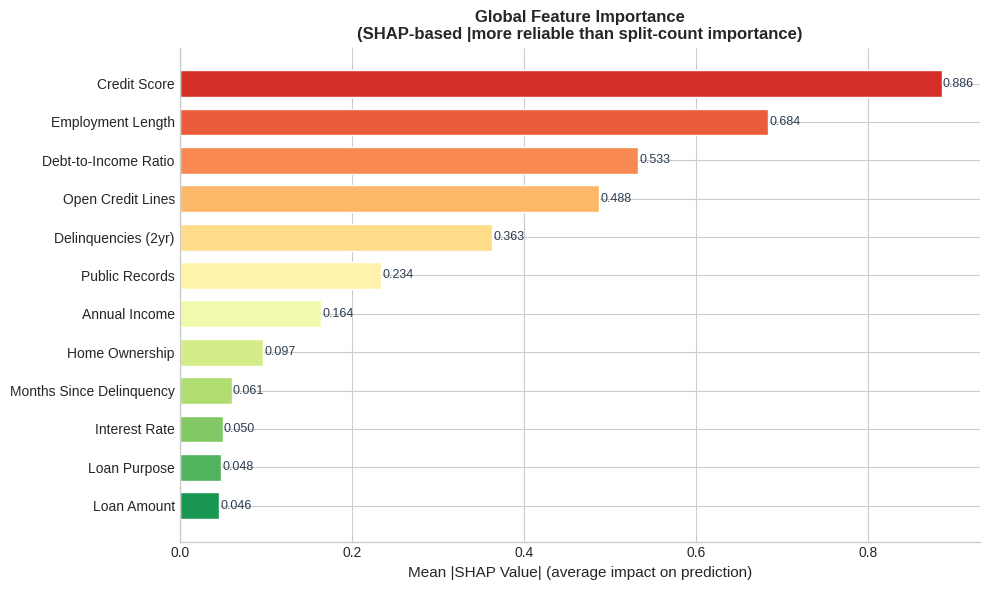


 Credit score dominates |this aligns perfectly with domain knowledge in lending.


In [24]:

# CELL 9 |GLOBAL EXPLAINABILITY: Feature Importance (SHAP-based)
# Mean |SHAP| across all predictions = global feature importance
# Much more reliable than XGBoost's built-in feature_importances_!


feature_names = preprocessor.feature_names_out

# Mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_vals_pos).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True)

# Human-readable feature name mapping
feature_display = {
    'credit_score': 'Credit Score',
    'dti': 'Debt-to-Income Ratio',
    'annual_income': 'Annual Income',
    'loan_amount': 'Loan Amount',
    'interest_rate': 'Interest Rate',
    'emp_length_yrs': 'Employment Length',
    'num_credit_lines': 'Open Credit Lines',
    'delinq_2yrs': 'Delinquencies (2yr)',
    'months_since_last_delinq': 'Months Since Delinquency',
    'pub_rec': 'Public Records',
    'home_ownership': 'Home Ownership',
    'loan_purpose': 'Loan Purpose'
}

importance_df['display_name'] = importance_df['feature'].map(feature_display)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importance_df['display_name'], importance_df['mean_abs_shap'],
               color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(importance_df))),
               edgecolor='white', height=0.7)

for bar, val in zip(bars, importance_df['mean_abs_shap']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#2c3e50')

ax.set_xlabel('Mean |SHAP Value| (average impact on prediction)', fontsize=11)
ax.set_title('Global Feature Importance\n(SHAP-based |more reliable than split-count importance)',
             fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Credit score dominates |this aligns perfectly with domain knowledge in lending.')

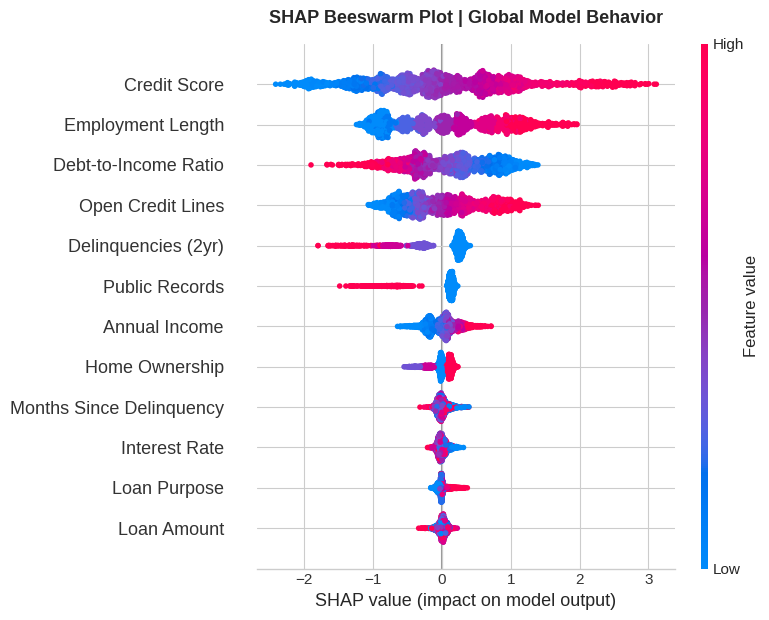

Reading this chart:
  • Credit Score: HIGH score (red) → positive SHAP → increases approval probability ✅
  • DTI         : HIGH DTI (red) → negative SHAP → decreases approval probability ❌
  • This is exactly what a lending expert would expect | model makes sense!


In [25]:
# CELL 10 | GLOBAL EXPLAINABILITY: SHAP Beeswarm Plot
# Each dot = one applicant. X-axis = SHAP value (impact on prediction).
# Color = feature value (red = high, blue = low).

import shap
import matplotlib.pyplot as plt
import numpy as np

# Build Explanation object using the pre-computed scalar expected_value
# (avoids broadcasting errors when expected_value is an array in XGBoost ≥ 2.x)
shap_explanation = shap.Explanation(
    values=shap_vals_pos,
    base_values=np.full(len(X_test), expected_value),   # scalar, safe for all versions
    data=X_test.values,
    feature_names=[feature_display.get(f, f) for f in feature_names]
)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_explanation, max_display=12, show=False)
plt.title('SHAP Beeswarm Plot | Global Model Behavior', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reading this chart:')
print('  • Credit Score: HIGH score (red) → positive SHAP → increases approval probability ✅')
print('  • DTI         : HIGH DTI (red) → negative SHAP → decreases approval probability ❌')
print('  • This is exactly what a lending expert would expect | model makes sense!')


In [26]:
# CELL 11 | LOCAL EXPLANATION FUNCTION
# Generates a waterfall chart + plain-English explanation for one applicant.

def explain_single_prediction(idx, X_test, y_test, model, explainer, preprocessor,
                               feature_display, artifacts_dir):
    """Generate a complete SHAP-based explanation for one applicant."""

    sample = X_test.iloc[[idx]]
    prob   = model.predict_proba(sample)[0, 1]
    actual = y_test.iloc[idx]

    # SHAP waterfall explanation
    shap_vals = explainer(sample)
    shap_pos  = shap_vals.values[0, :]

    # Safely extract scalar baseline (XGBoost ≥ 2.x returns a 1-element array)
    base_val = float(np.ravel(explainer.expected_value)[0])

    # Top contributing features
    contribs = sorted(
        zip(preprocessor.feature_names_out, shap_pos, sample.values[0]),
        key=lambda x: abs(x[1]), reverse=True
    )

    # Waterfall chart
    top_n = 8
    features, values, raw_vals = zip(*contribs[:top_n])
    display_names = [feature_display.get(f, f) for f in features]

    fig, ax = plt.subplots(figsize=(11, 6))
    running = base_val
    for i, (name, val, raw) in enumerate(zip(display_names, values, raw_vals)):
        color = '#2ecc71' if val > 0 else '#e74c3c'
        ax.barh(i, val, left=running, color=color, edgecolor='white', height=0.6)
        label_x = running + val + (0.005 if val >= 0 else -0.005)
        ha = 'left' if val >= 0 else 'right'
        ax.text(label_x, i, f'{val:+.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')
        ax.text(-0.01, i, f'{name}\n({raw:.1f})', va='center', ha='right', fontsize=8, color='#555')
        running += val

    ax.axvline(base_val, color='#7f8c8d', linestyle='--', lw=1.5, label=f'Baseline ({base_val:.3f})')
    ax.axvline(prob,     color='#2c3e50', linestyle='-',  lw=2,   label=f'Prediction ({prob:.3f})')

    decision = 'APPROVED ✅' if prob >= 0.5 else 'REJECTED ❌'
    ax.set_title(f'Applicant #{idx} | {decision}  |  Approval Probability: {prob:.1%}',
                  fontsize=12, fontweight='bold')
    ax.set_yticks([])
    ax.set_xlabel('SHAP Contribution to Approval Probability (log-odds)', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.spines[['top','right','left']].set_visible(False)
    plt.tight_layout()
    plt.savefig(artifacts_dir / f'explanation_sample_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Human-readable text explanation
    positive_factors = [(feature_display.get(f,f), v, r) for f,v,r in contribs if v > 0][:3]
    negative_factors = [(feature_display.get(f,f), v, r) for f,v,r in contribs if v < 0][:3]

    lines = [f"\n{'='*60}", f"  LOAN DECISION EXPLANATION | Applicant #{idx}", f"{'='*60}",
             f"  Decision       : {decision}",
             f"  Approval Score : {prob:.1%} (threshold: 50%)",
             f"  Actual Label   : {'Approved' if actual else 'Rejected'}",
             "", "  ✅ Factors working IN YOUR FAVOR:"]
    for name, val, raw in positive_factors:
        lines.append(f"     + {name}: {raw:.1f}  (contribution: +{val:.3f})")
    lines += ["", "  ❌ Factors working AGAINST your application:"]
    for name, val, raw in negative_factors:
        lines.append(f"     - {name}: {raw:.1f}  (contribution: {val:.3f})")
    lines.append(f"{'='*60}")

    explanation_text = '\n'.join(lines)
    print(explanation_text)
    return explanation_text


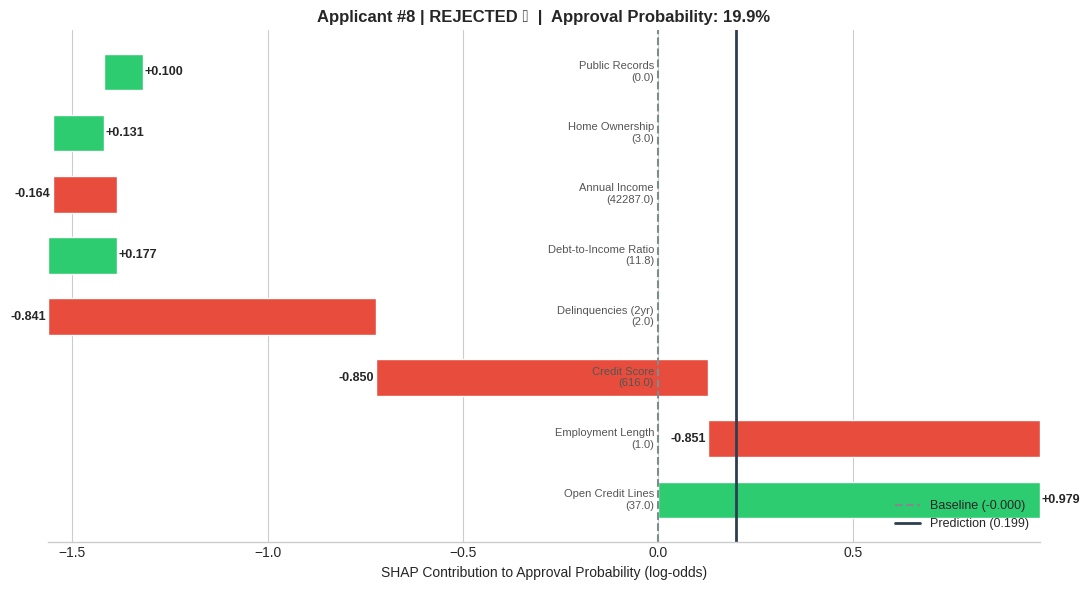


  LOAN DECISION EXPLANATION | Applicant #8
  Decision       : REJECTED ❌
  Approval Score : 19.9% (threshold: 50%)
  Actual Label   : Rejected

  ✅ Factors working IN YOUR FAVOR:
     + Open Credit Lines: 37.0  (contribution: +0.979)
     + Debt-to-Income Ratio: 11.8  (contribution: +0.177)
     + Home Ownership: 3.0  (contribution: +0.131)

  ❌ Factors working AGAINST your application:
     - Employment Length: 1.0  (contribution: -0.851)
     - Credit Score: 616.0  (contribution: -0.850)
     - Delinquencies (2yr): 2.0  (contribution: -0.841)


'\n============================================================\n  LOAN DECISION EXPLANATION | Applicant #8\n============================================================\n  Decision       : REJECTED ❌\n  Approval Score : 19.9% (threshold: 50%)\n  Actual Label   : Rejected\n\n  ✅ Factors working IN YOUR FAVOR:\n     + Open Credit Lines: 37.0  (contribution: +0.979)\n     + Debt-to-Income Ratio: 11.8  (contribution: +0.177)\n     + Home Ownership: 3.0  (contribution: +0.131)\n\n  ❌ Factors working AGAINST your application:\n     - Employment Length: 1.0  (contribution: -0.851)\n     - Credit Score: 616.0  (contribution: -0.850)\n     - Delinquencies (2yr): 2.0  (contribution: -0.841)\n============================================================'

In [27]:
# CELL 12 | LOCAL EXPLANATION: Rejected Applicant
# Showing a rejected applicant is MORE important than an approved one —
# this is what regulators and compliance teams want to see!

rejected_idx   = y_test[y_test == 0].index[5]       # pick a rejected sample
rejected_pos   = X_test.index.get_loc(rejected_idx)  # positional index in X_test

# Reset y_test index so iloc-based lookup inside the function is consistent
explain_single_prediction(
    rejected_pos,
    X_test,
    y_test.reset_index(drop=True),   # align positional index with X_test
    model, explainer, preprocessor, feature_display, ARTIFACTS_DIR
)


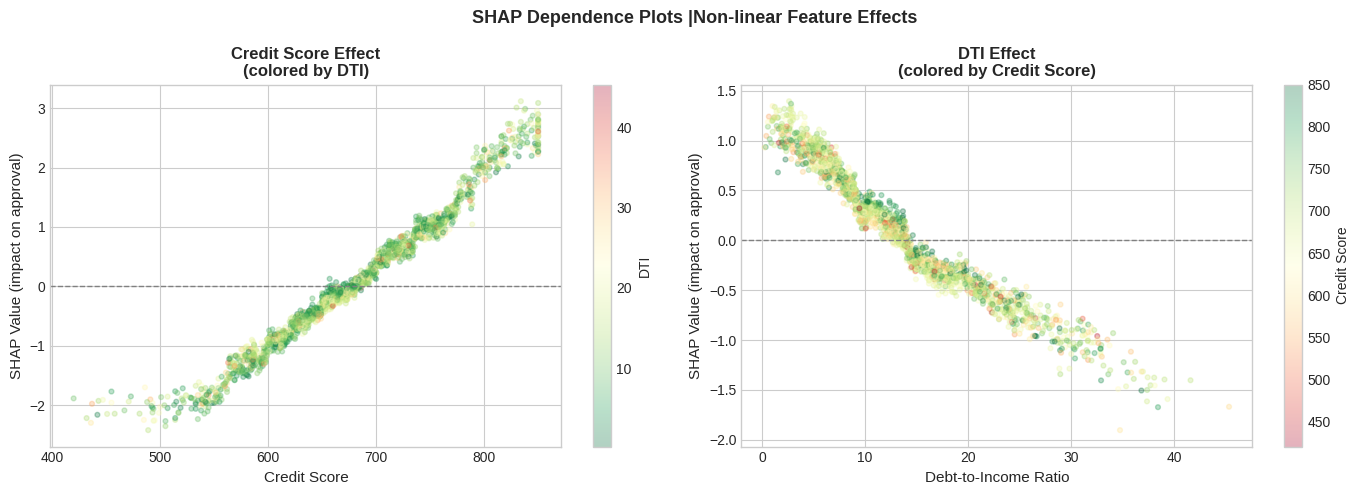

Key insights:
  • Credit score has a clear non-linear threshold effect around 650-700
  • DTI impact is stronger when credit score is low (red dots in right chart)
  • This interaction is automatically captured by XGBoost + SHAP!


In [28]:

# CELL 13 |GLOBAL XAI: SHAP Dependence Plots
# Shows HOW each feature affects predictions across its value range
# Reveals non-linear relationships and interaction effects


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit score dependence
cs_idx = preprocessor.feature_names_out.index('credit_score')
dti_idx = preprocessor.feature_names_out.index('dti')

scatter_kw = dict(alpha=0.3, s=12)

sc1 = axes[0].scatter(X_test.values[:, cs_idx], shap_vals_pos[:, cs_idx],
                       c=X_test.values[:, dti_idx], cmap='RdYlGn_r', **scatter_kw)
axes[0].axhline(0, color='gray', lw=1, linestyle='--')
axes[0].set_xlabel('Credit Score', fontsize=11)
axes[0].set_ylabel('SHAP Value (impact on approval)', fontsize=11)
axes[0].set_title('Credit Score Effect\n(colored by DTI)', fontweight='bold')
plt.colorbar(sc1, ax=axes[0], label='DTI')

sc2 = axes[1].scatter(X_test.values[:, dti_idx], shap_vals_pos[:, dti_idx],
                       c=X_test.values[:, cs_idx], cmap='RdYlGn', **scatter_kw)
axes[1].axhline(0, color='gray', lw=1, linestyle='--')
axes[1].set_xlabel('Debt-to-Income Ratio', fontsize=11)
axes[1].set_ylabel('SHAP Value (impact on approval)', fontsize=11)
axes[1].set_title('DTI Effect\n(colored by Credit Score)', fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='Credit Score')

plt.suptitle('SHAP Dependence Plots |Non-linear Feature Effects', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insights:')
print('  • Credit score has a clear non-linear threshold effect around 650-700')
print('  • DTI impact is stronger when credit score is low (red dots in right chart)')
print('  • This interaction is automatically captured by XGBoost + SHAP!')


🔍 Fairness Analysis by Home Ownership:
                      approval_rate  avg_probability  n_applicants
home_ownership_label                                              
MORTGAGE                      0.518            0.537           762
OTHER                         0.500            0.517            70
OWN                           0.510            0.545           192
RENT                          0.566            0.551           851


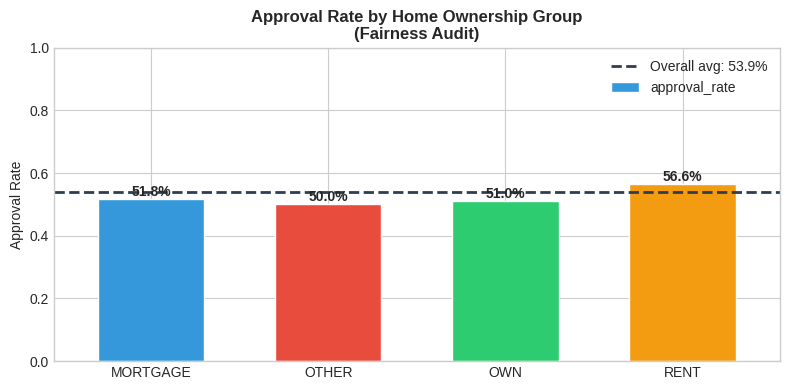


⚠️  Real-world note: Protected attributes (race, gender, age) must NEVER be used as
   direct features. Proxy features (zip code, home ownership) can still encode bias.
   Use Fairlearn, AIF360, or similar libraries for formal fairness constraints.


In [29]:

# CELL 14 |BIAS & FAIRNESS ANALYSIS
# Production AI must check for discriminatory patterns.
# We check if approval rates differ by home ownership type
# (a proxy for socioeconomic status)


# Map encoded home_ownership back to labels
ho_encoder = preprocessor.label_encoders['home_ownership']
X_test_copy = X_test.copy()
X_test_copy['home_ownership_label'] = ho_encoder.inverse_transform(
    X_test_copy['home_ownership'].astype(int))
X_test_copy['predicted_prob'] = y_pred_proba
X_test_copy['predicted_label'] = y_pred
X_test_copy['true_label'] = y_test.values

fairness = X_test_copy.groupby('home_ownership_label').agg(
    approval_rate=('predicted_label', 'mean'),
    avg_probability=('predicted_prob', 'mean'),
    n_applicants=('predicted_label', 'count')
).round(3)

print('\n🔍 Fairness Analysis by Home Ownership:')
print(fairness.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
fairness['approval_rate'].plot(kind='bar', ax=ax, color=['#3498db','#e74c3c','#2ecc71','#f39c12'],
                                edgecolor='white', width=0.6)
ax.axhline(y_pred.mean(), color='#2c3e50', linestyle='--', lw=2, label=f'Overall avg: {y_pred.mean():.1%}')
ax.set_title('Approval Rate by Home Ownership Group\n(Fairness Audit)', fontweight='bold')
ax.set_ylabel('Approval Rate')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend()
ax.set_ylim(0, 1)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'fairness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n⚠️  Real-world note: Protected attributes (race, gender, age) must NEVER be used as')
print('   direct features. Proxy features (zip code, home ownership) can still encode bias.')
print('   Use Fairlearn, AIF360, or similar libraries for formal fairness constraints.')

---
## 💾 Step 6: Save All Artifacts for Production Serving

In [30]:
import json
import pandas as pd

# Save model metadata | version tracking is essential in production
metadata = {
    'model_version':   '1.0.0',
    'trained_at':      pd.Timestamp.now().isoformat(),
    'features':        preprocessor.feature_names_out,
    'feature_display': feature_display,
    'threshold':       0.50,
    'test_auc':        float(round(auc, 4)),
    'test_f1':         float(round(f1, 4)),
    'n_train_samples': len(X_train_resampled),
    'n_test_samples':  len(X_test),
    'baseline_value':  float(explainer.expected_value)  # scalar for binary
}

# Save JSON
with open(ARTIFACTS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Verify all artifacts

for f in sorted(ARTIFACTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'   {f.name:<35} {size_kb:>8.1f} KB')

print(f'\nAll artifacts ready for production serving!')
print(f'   API server loads: xgb_model.pkl + preprocessor.pkl + shap_explainer.pkl')

   eda_overview.png                       213.9 KB
   evaluation_plots.png                   109.1 KB
   explanation_sample_294.png              85.8 KB
   explanation_sample_8.png                81.9 KB
   fairness_analysis.png                   46.6 KB
   global_importance.png                   93.6 KB
   model_metadata.json                      1.0 KB
   preprocessor.pkl                         1.1 KB
   shap_beeswarm.png                      169.6 KB
   shap_dependence.png                    253.0 KB
   shap_explainer.pkl                    2376.2 KB
   xgb_model.pkl                          694.8 KB

All artifacts ready for production serving!
   API server loads: xgb_model.pkl + preprocessor.pkl + shap_explainer.pkl


---
## 📋 Summary & Next Steps

### ✅ What we built

| Component | Status | Details |
|-----------|--------|--------|
| Data Pipeline | ✅ | LoanPreprocessor with label encoding, SMOTE |
| Model | ✅ | XGBoost, 5-fold CV, early stopping |
| Evaluation | ✅ | ROC-AUC, F1, PR curve, confusion matrix |
| Global XAI | ✅ | SHAP beeswarm, feature importance, dependence plots |
| Local XAI | ✅ | Per-applicant waterfall charts + text explanation |
| Fairness | ✅ | Group-level approval rate audit |
| Artifacts | ✅ | model.pkl, preprocessor.pkl, explainer.pkl, metadata.json |

### 🚀 What comes next
See `api/main.py` for the **FastAPI** serving layer and `ui/app.py` for the **Streamlit** UI.